---

## Data Loading & Understanding

In [14]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

### Step 1: Load the Dataset

In [15]:
# Load the Breast Cancer Wisconsin dataset
cancer = load_breast_cancer()
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = pd.Series(cancer.target, name='target')

# Create a full dataset DataFrame with target column
data_df = X.copy()
data_df['target'] = y

print(f"Dataset Shape: {data_df.shape}")
print(f"Number of Samples: {data_df.shape[0]}")
print(f"Number of Features: {data_df.shape[1] - 1}")
print(f"Number of Classes: {y.nunique()}")
print("\nFirst 5 rows:")
print(data_df.head())

class_distribution = y.value_counts().sort_index()
class_names = {0: 'Malignant', 1: 'Benign'}
print("\nClass Distribution:")
for class_idx, count in class_distribution.items():
    print(f"  {class_names[class_idx]}: {count} samples ({count/len(y)*100:.2f}%)")

Dataset Shape: (569, 31)
Number of Samples: 569
Number of Features: 30
Number of Classes: 2

First 5 rows:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430     

### Step 2: Clean the Data

In [16]:
# Check data quality
missing_values = data_df.isnull().sum()
print(f"Missing values: {missing_values.sum()}")

duplicate_count = data_df.duplicated().sum()
print(f"Duplicate rows: {duplicate_count}")

non_numeric_features = data_df.select_dtypes(exclude=[np.number]).columns
print(f"Non-numeric features: {len(non_numeric_features)}")

unique_classes = np.unique(y)
print(f"Unique classes: {unique_classes}")
print(f"✓ Dataset is clean: {data_df.shape}")

Missing values: 0
Duplicate rows: 0
Non-numeric features: 0
Unique classes: [0 1]
✓ Dataset is clean: (569, 31)


### Step 3: Perform Simple EDA (Exploratory Data Analysis)

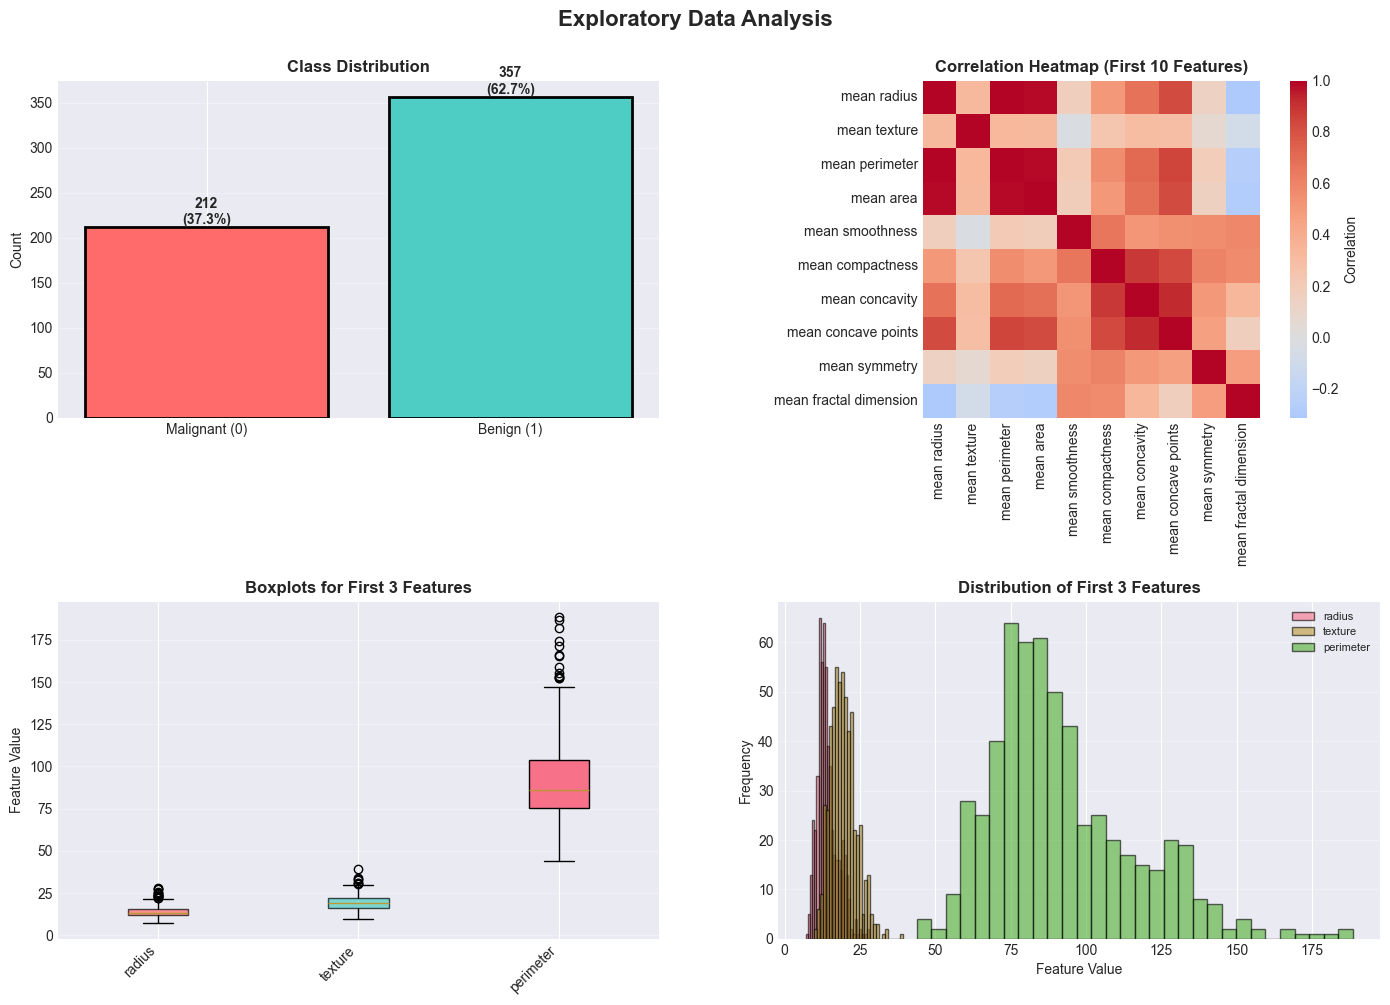

In [17]:
# Set up matplotlib style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Create a figure with multiple subplots for EDA
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Exploratory Data Analysis', fontsize=16, fontweight='bold', y=1.00)

# Plot 1: Class Distribution
class_counts = y.value_counts().sort_index()
colors = ['#FF6B6B', '#4ECDC4']
ax = axes[0, 0]
bars = ax.bar(['Malignant (0)', 'Benign (1)'], class_counts.values, color=colors, edgecolor='black', linewidth=2)
ax.set_title('Class Distribution', fontsize=12, fontweight='bold')
ax.set_ylabel('Count', fontsize=10)
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}\n({height/len(y)*100:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Plot 2: Correlation Heatmap (top 10 features for visibility)
ax = axes[0, 1]
feature_cols = data_df.columns[:-1]  # Exclude target
corr_matrix = data_df[feature_cols].corr()
# Show only first 10 features to make heatmap readable
sns.heatmap(corr_matrix.iloc[:10, :10], annot=False, cmap='coolwarm', center=0, 
            square=True, ax=ax, cbar_kws={'label': 'Correlation'})
ax.set_title('Correlation Heatmap (First 10 Features)', fontsize=12, fontweight='bold')

# Plot 3: Boxplots for selected features
ax = axes[1, 0]
selected_features = feature_cols[:3]  # First 3 features
data_for_boxplot = []
labels = []
for feat in selected_features:
    data_for_boxplot.append(data_df[feat].values)
    # Shorten feature names for readability
    short_name = feat.replace('mean', '').replace('(', '').replace(')', '').strip()[:15]
    labels.append(short_name)

bp = ax.boxplot(data_for_boxplot, labels=labels, patch_artist=True)
for patch, color in zip(bp['boxes'], colors[:len(bp['boxes'])]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('Boxplots for First 3 Features', fontsize=12, fontweight='bold')
ax.set_ylabel('Feature Value', fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Plot 4: Distribution plots for selected features
ax = axes[1, 1]
for i, feat in enumerate(selected_features):
    ax.hist(data_df[feat], bins=30, alpha=0.6, label=feat.replace('mean', '').strip()[:10], edgecolor='black')
ax.set_title('Distribution of First 3 Features', fontsize=12, fontweight='bold')
ax.set_xlabel('Feature Value', fontsize=10)
ax.set_ylabel('Frequency', fontsize=10)
ax.legend(loc='upper right', fontsize=8)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('eda_visualization.png', dpi=100, bbox_inches='tight')
plt.show()

In [18]:
# Generate EDA Summary Report
benign_count = len(y[y == 1])
malignant_count = len(y[y == 0])
benign_pct = benign_count / len(y) * 100
malignant_pct = malignant_count / len(y) * 100
ratio = benign_count / malignant_count

print("\nClass Balance:")
print(f"  Benign: {benign_count} ({benign_pct:.2f}%), Malignant: {malignant_count} ({malignant_pct:.2f}%)")
print(f"  Ratio: {ratio:.2f}:1 - Relatively balanced" if 0.7 <= ratio <= 1.5 else "  Imbalanced")

feature_cols = data_df.columns[:-1]
correlations_with_target = data_df[feature_cols].corrwith(y).abs().sort_values(ascending=False)
print(f"\nTop 5 features correlated with target:")
for i, (feat, corr) in enumerate(correlations_with_target.head(5).items(), 1):
    print(f"  {i}. {feat}: {corr:.4f}")

Q1 = data_df[feature_cols].quantile(0.25)
Q3 = data_df[feature_cols].quantile(0.75)
IQR = Q3 - Q1
outliers_count = ((data_df[feature_cols] < (Q1 - 1.5 * IQR)) | 
                  (data_df[feature_cols] > (Q3 + 1.5 * IQR))).sum().sum()
print(f"\nOutliers (IQR): {outliers_count} ({outliers_count/(data_df[feature_cols].size)*100:.2f}%)")

skewness = data_df[feature_cols].skew().abs()
print(f"Features with high skewness: {(skewness > 1).sum()}")
print(f"\n✓ Ready for next steps")


Class Balance:
  Benign: 357 (62.74%), Malignant: 212 (37.26%)
  Imbalanced

Top 5 features correlated with target:
  1. worst concave points: 0.7936
  2. worst perimeter: 0.7829
  3. mean concave points: 0.7766
  4. worst radius: 0.7765
  5. mean perimeter: 0.7426

Outliers (IQR): 608 (3.56%)
Features with high skewness: 22

✓ Ready for next steps


---

## Data Preparation

### Step 4: Prepare Features and Target

In [19]:
# Prepare features and target
X = data_df.iloc[:, :-1]  # All features except target
y = data_df.iloc[:, -1]   # Target column

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Binary classes: {np.unique(y)}")
print(f"✓ Features and Target prepared")

Features shape: (569, 30)
Target shape: (569,)
Binary classes: [0 1]
✓ Features and Target prepared


### Step 5: Train-Test Split

In [20]:
# Split data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # Preserve class distribution
)

print(f"Training set: X_train {X_train.shape}, y_train {y_train.shape}")
print(f"Testing set: X_test {X_test.shape}, y_test {y_test.shape}")
print(f"Train/Test ratio: {len(X_train)}/{len(X_test)}")
print(f"✓ Train-Test split completed")

Training set: X_train (455, 30), y_train (455,)
Testing set: X_test (114, 30), y_test (114,)
Train/Test ratio: 455/114
✓ Train-Test split completed


### Step 6: Scale the Data (No Data Leakage)

In [21]:
# Initialize scaler
scaler = StandardScaler()

# Fit scaler ONLY on training data (avoid data leakage)
X_train_scaled = scaler.fit_transform(X_train)

# Apply same scaler to test data
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrames for easier handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print(f"Scaled training set: {X_train_scaled.shape}")
print(f"Scaled testing set: {X_test_scaled.shape}")
print(f"Feature mean (train): {X_train_scaled.mean().mean():.4f}")
print(f"Feature std (train): {X_train_scaled.std().mean():.4f}")
print(f"✓ Data scaled without data leakage")

Scaled training set: (455, 30)
Scaled testing set: (114, 30)
Feature mean (train): 0.0000
Feature std (train): 1.0011
✓ Data scaled without data leakage


---

## Model Building

In [ ]:
# Install and import TensorFlow (CPU-only, lightweight)
import subprocess
import sys

print("Installing TensorFlow (CPU version - smaller download)...")
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "tensorflow-cpu"])

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Sequential
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report, 
                             roc_curve, auc)

print("TensorFlow version:", tf.__version__)
print("✓ Deep Learning libraries imported")

Installing TensorFlow (CPU version - smaller download)...


### Step 7: Build ANN Architecture

In [ ]:
# Build ANN model
model = Sequential([
    layers.Input(shape=(30,)),  # 30 input features
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # Binary classification
])

# Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall()]
)

print("Model Architecture:")
model.summary()
print("\n✓ ANN model built and compiled")

---

## Model Training & Evaluation

### Step 8: Train the Model

In [ ]:
# Define early stopping to prevent overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=0
)

# Train the model
history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

print(f"Training completed")
print(f"Total epochs trained: {len(history.history['loss'])}")
print(f"Final training loss: {history.history['loss'][-1]:.4f}")
print(f"Final validation loss: {history.history['val_loss'][-1]:.4f}")
print(f"✓ Model trained")

### Step 9: Plot Training History

In [ ]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_title('Model Loss', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_title('Model Accuracy', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Training history plotted")

### Step 10: Evaluate on Test Set

In [ ]:
# Make predictions on test set
y_pred_proba = model.predict(X_test_scaled, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# Calculate metrics
test_loss, test_accuracy, test_precision, test_recall = model.evaluate(
    X_test_scaled, y_test, verbose=0
)

f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Test Set Performance:")
print(f"  Loss: {test_loss:.4f}")
print(f"  Accuracy: {test_accuracy:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall: {test_recall:.4f}")
print(f"  F1-Score: {f1:.4f}")
print(f"\nConfusion Matrix:")
print(cm)
print(f"\n✓ Model evaluated")

### Step 11: Performance Visualization

In [ ]:
# Create performance visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'])
axes[0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=12, fontweight='bold')
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_performance.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"ROC-AUC Score: {roc_auc:.4f}")
print("✓ Performance visualizations created")